In [1]:
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu
from statannotations.Annotator import Annotator

In [2]:
data = pd.read_excel('../data.xlsx')
data.columns = [col.split(' (')[0] if ":" in col else col for col in data.columns]
data['Normal fertilization'] = data['Normal fertilization'].replace({0: 'abnormal', 1: 'normal'})

interpret_result = pd.read_csv('./interpret_result.csv')
predict_result = pd.read_csv('./predictions.csv')
predict_result['targets'] = predict_result['targets'].replace({0: 'normal', 1: 'abnormal'})

interpret_result.columns = data.drop(columns=["ID", "Normal fertilization"]).columns
result = pd.concat([predict_result, interpret_result], axis=1)
result


,predictions,targets,Patient age,Partner age,Previous IVF cycles,Infertility type,Male factors cause infertility,Female factors cause infertility,Years of infertility,Body Mass Index (BMI),...,IM (Immotile) sperm count before semen optimization treatment,Total sperm count before semen optimization treatment (x10^6),Volume after semen optimization treatment,Concentration after semen optimization treatment,PR sperm count after semen optimization treatment,NP sperm count after semen optimization treatment,IM sperm count after semen optimization treatment,Number of oocyte for IVF,Number of oocyte for ICSI,Number of MII oocyte for ICSI
0,0.074489,normal,0.072651,0.072651,0.016778,0.016778,0.016778,0.016778,0.081541,0.142475,...,0.017475,0.057376,0.007746,-0.287740,0.057851,0.081541,0.081541,-0.027672,0.000000,0.000000
1,0.049074,normal,0.060204,0.048895,0.006326,0.000000,0.006326,0.000000,-0.046502,0.079233,...,0.000604,-0.002922,0.004167,-0.046502,-0.003286,-0.051918,0.075976,0.000000,-0.071911,-0.071911
2,0.357884,normal,0.141140,0.099781,0.016555,0.000000,0.016555,0.000000,0.016555,0.199709,...,-0.017117,NaN,0.008406,0.016555,0.000000,0.000000,-0.017117,0.000000,-0.156026,-0.156026
3,0.136964,normal,0.080710,0.062414,-0.034180,0.000000,0.000000,-0.034180,-0.034180,0.130657,...,0.036930,0.036089,0.007465,-0.258806,0.033833,-0.061641,0.017500,0.701076,0.000000,0.000000
4,0.173919,normal,0.115116,0.117835,-0.038464,0.000000,-0.038464,0.000000,0.091874,0.125398,...,0.036373,0.037658,0.008517,-0.031324,0.000000,0.000000,0.036373,0.000000,0.037605,0.037605
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1228,0.250619,abnormal,0.026554,0.025417,-0.336876,0.000000,0.000000,0.007569,0.021044,0.042247,...,0.025419,0.063406,0.010057,0.013310,0.030292,0.013310,0.037108,0.000000,0.007569,0.007569
1229,0.071425,normal,0.070986,0.061700,0.008684,0.008684,0.000000,0.008684,0.008684,0.083941,...,0.012654,-0.018679,0.006879,-0.154754,0.002062,-0.127206,-0.127206,0.011183,0.000000,0.000000
1230,0.255810,normal,0.069509,0.066259,0.022376,0.000000,-0.031084,-0.031084,-0.031084,0.006126,...,0.064628,0.125340,0.015831,-0.034878,0.138233,0.123501,0.123501,-0.031084,0.000000,0.000000
1231,0.046477,normal,0.041030,0.030981,0.021634,0.021634,0.000000,0.021634,-0.061999,0.090270,...,0.015947,0.005203,0.012798,-0.174266,0.000437,-0.899569,-0.288753,0.091682,0.000000,0.000000


ROC AUC Score: 0.8497138664710198
ROC AUC Score: 0.7627404365679706


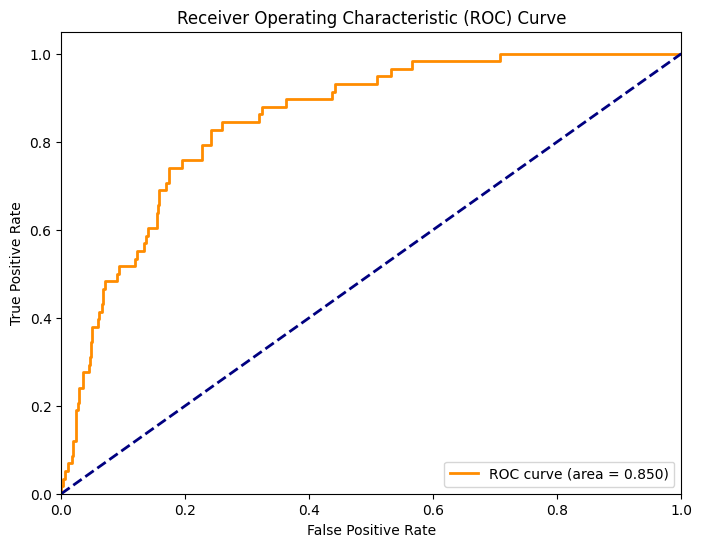

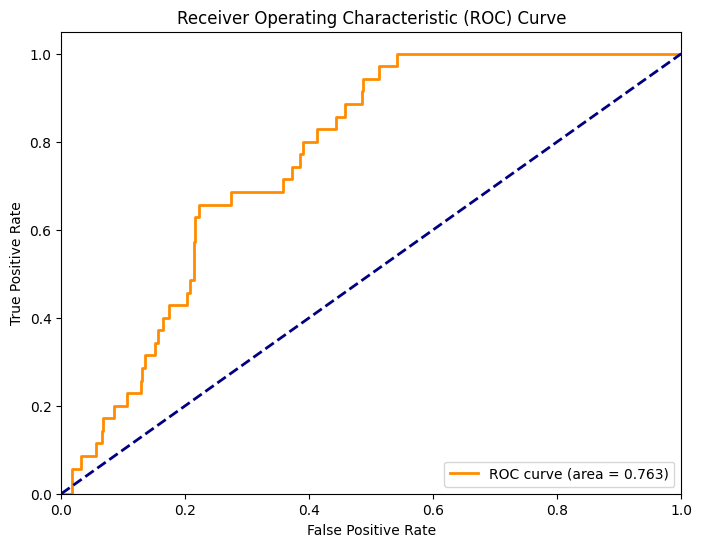

In [3]:
from sklearn.metrics import roc_auc_score, roc_curve


def plot_roc_curve(predictions, filename):
    roc_auc = roc_auc_score(predictions["targets"], predictions["predictions"])
    print(f"ROC AUC Score: {roc_auc}")
    fpr, tpr, _ = roc_curve(predictions["targets"], predictions["predictions"])

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2,
                label=f'ROC curve (area = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")

    plt.savefig(filename, format="pdf", bbox_inches="tight")

plot_roc_curve(pd.read_csv('./predictions.csv'), "roc_curve.validate.pdf")
plot_roc_curve(pd.read_csv('./predictions.20250829.csv'), "roc_curve.20250829.pdf")

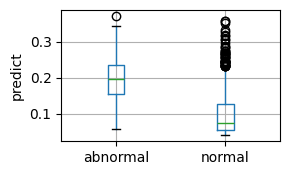

In [4]:
boxplot = result.boxplot(column=["predictions"], by="targets", figsize=(3, 2))

plt.suptitle('')
plt.title('')
plt.xlabel('')
plt.ylabel('predict')
plt.tight_layout()
plt.show()

/data/li-ming-hong/miniconda3/envs/ivf/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


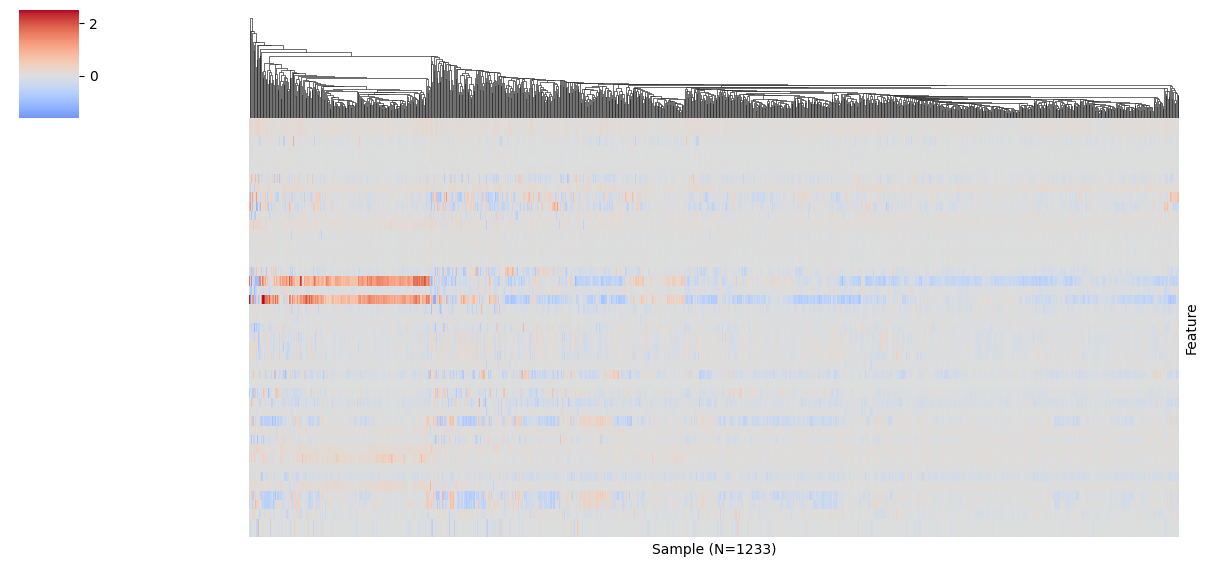

In [5]:
_df = result.drop(columns=predict_result.columns).copy()
_df = _df.map(lambda x: np.sign(x) * np.log1p(np.abs(x)))

# _colors = pd.DataFrame(
#     {
#         "target": ["green" if c == "normal" else "red" for c in result["targets"].values],
#         "predict > 0.1": ["white" if c < 0.1 else "black" for c in result["predictions"].values]
#     },
# )
g = sns.clustermap(
    data=_df.T.fillna(0), cmap='coolwarm', center=0, figsize=(12, 6), row_cluster=False,
    # col_colors=_colors,
    yticklabels=False
)
g.ax_heatmap.set_xlabel('Sample (N={})'.format(_df.shape[0]))
g.ax_heatmap.set_ylabel('Feature')
g.ax_heatmap.set_xticks([])

plt.savefig("{}.pdf".format("interpret_result"), format="pdf", bbox_inches="tight")
plt.show()

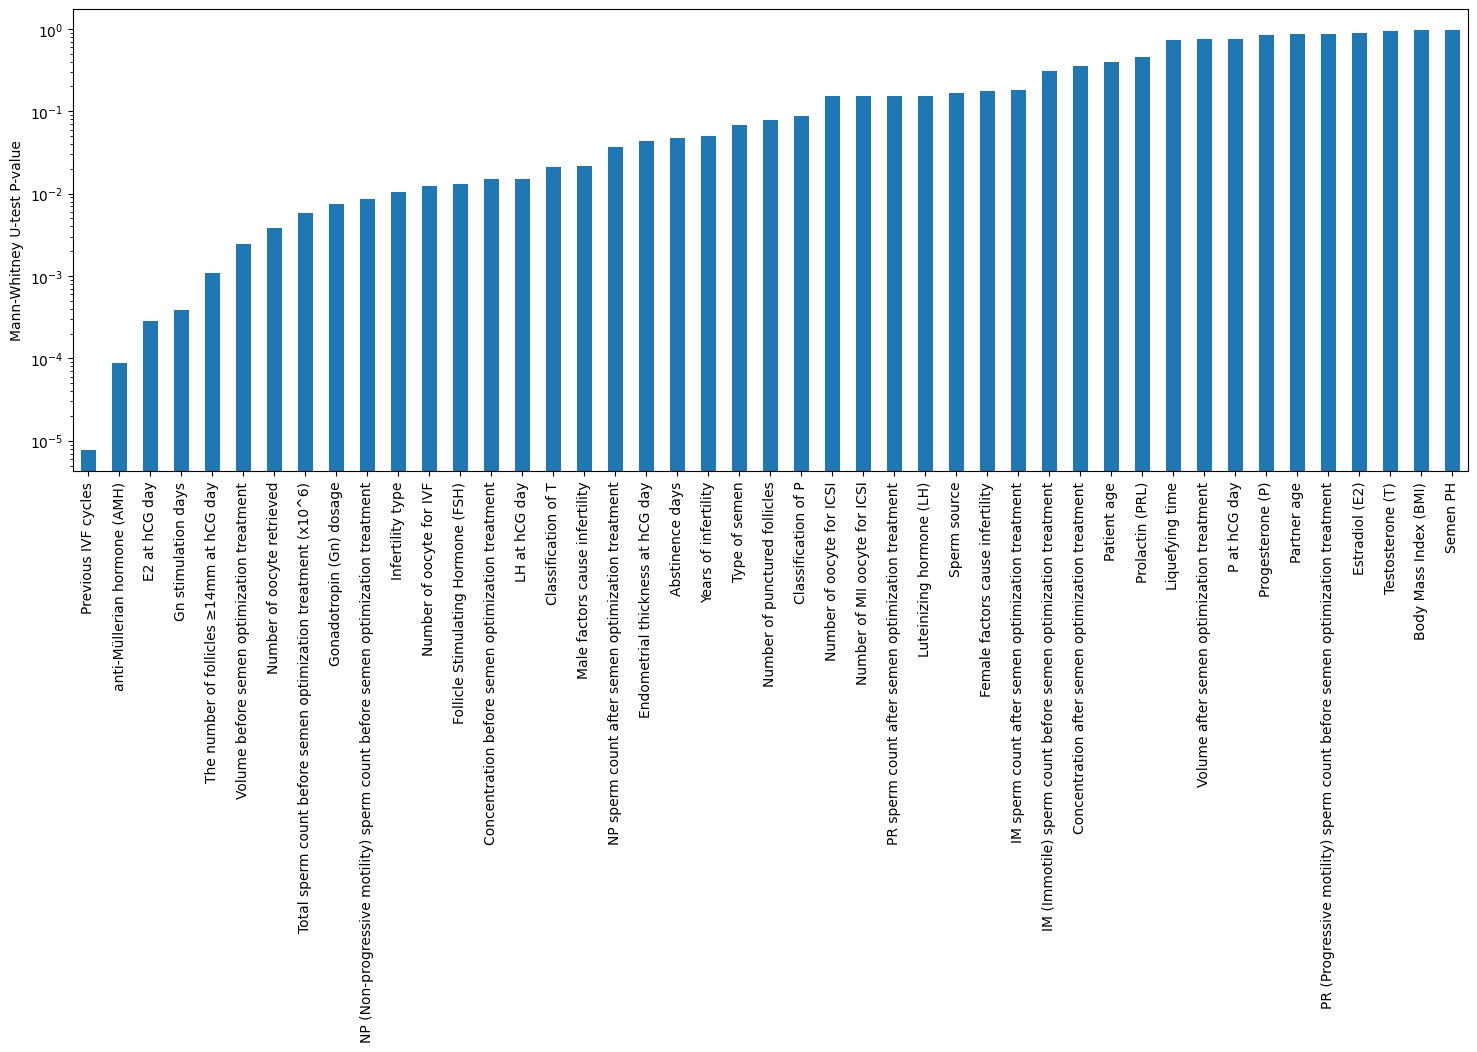

In [6]:
_normal = result[result["targets"] == 'normal'].drop(columns=predict_result.columns)
_abnormal = result[result["targets"] == 'abnormal'].drop(columns=predict_result.columns)

test_result = {}
for column in _normal.columns:
    _normal_clean = _normal[column][~np.isnan(_normal[column])]
    _abnormal_clean = _abnormal[column][~np.isnan(_abnormal[column])]
    u_stat, u_pvalue = mannwhitneyu(_normal_clean, _abnormal_clean, alternative='two-sided')
    
    test_result[column] = [u_pvalue]
test_result = pd.DataFrame(test_result)

ax = test_result.T.sort_values(by=0).plot(kind='bar', figsize=(18, 6), logy=True, legend=False)
plt.ylabel("Mann-Whitney U-test P-value")
plt.show()


Index(['Previous IVF cycles', 'anti-Müllerian hormone (AMH)', 'E2 at hCG day',
       'Gn stimulation days', 'The number of follicles ≥14mm at hCG day',
       'Volume before semen optimization treatment',
       'Number of oocyte retrieved',
       'Total sperm count before semen optimization treatment (x10^6)',
       'Gonadotropin (Gn) dosage',
       'NP (Non-progressive motility) sperm count before semen optimization treatment'],
      dtype='object')

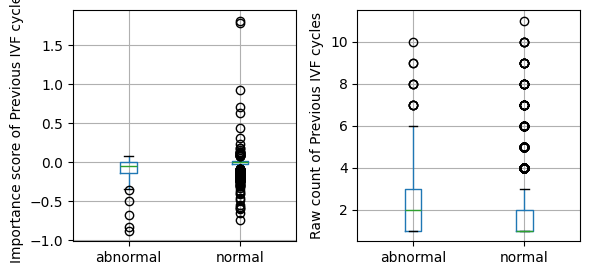

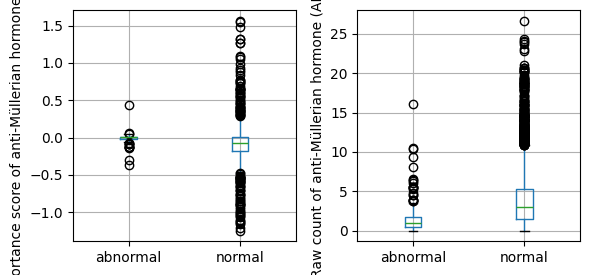

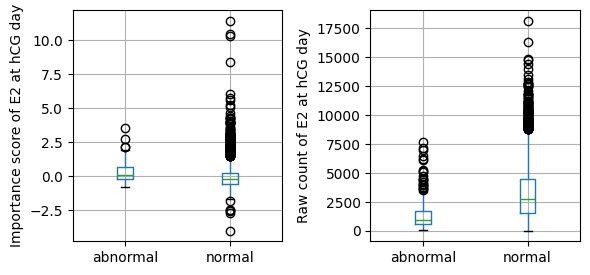

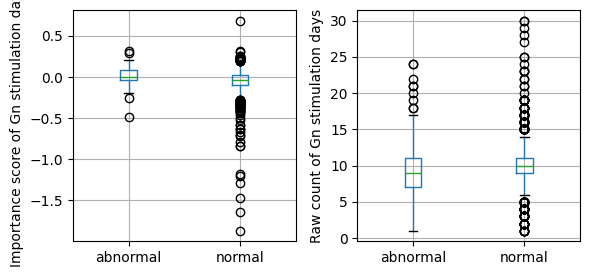

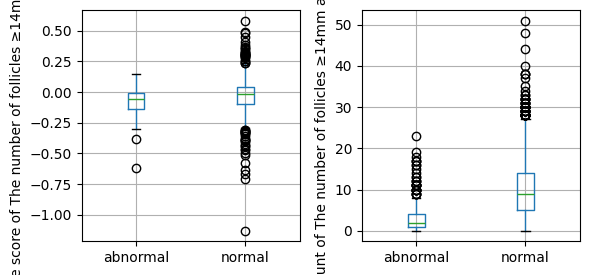

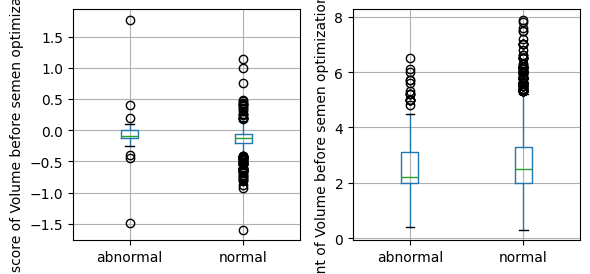

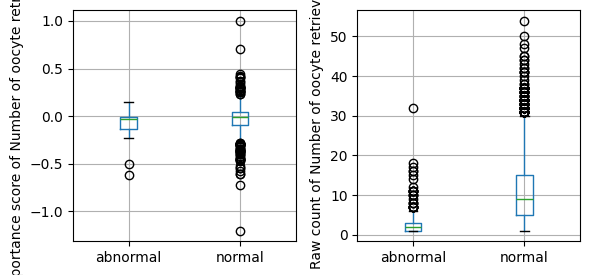

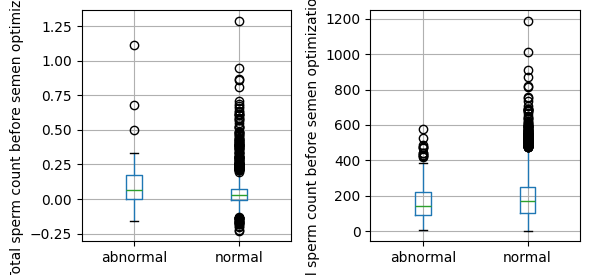

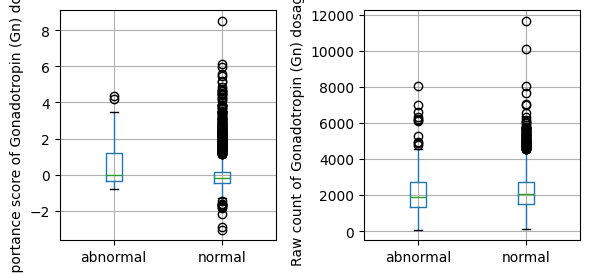

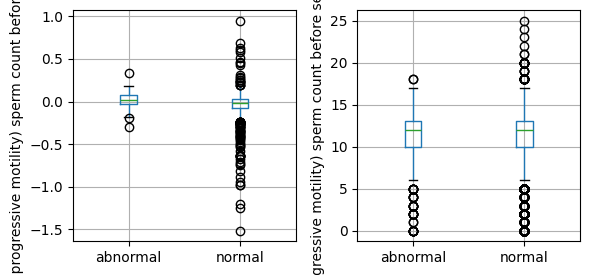

In [7]:
_tmp = test_result.T.sort_values(by=0)
_tmp = _tmp[_tmp[0] < 0.01]
display(_tmp.index)
for _index in _tmp.index:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 3))
    result.boxplot(column=[_index], by="targets", ax=axes[0])
    data.boxplot(column=[_index], by="Normal fertilization", ax=axes[1])

    plt.suptitle('')
    axes[0].set_title('')
    axes[0].set_xlabel('')
    axes[0].set_ylabel("Importance score of {}".format(_index))
    axes[1].set_title('')
    axes[1].set_xlabel('')
    axes[1].set_ylabel("Raw count of {}".format(_index))
    plt.tight_layout()
    plt.show()

In [8]:
suggest = pd.read_csv('suggest.csv', index_col=0)
suggest

,19,22,68,83,93,102,127,155,232,347,...,6012,6054,6080,6106,6112,6122,6143,6148,6155,6158
score,"[0.07831353694200516, 0.07792779058218002]","[0.1482958346605301, 0.08584404736757278]","[0.09749897569417953, 0.08314654976129532]","[0.23388303816318512, 0.20817038416862488]","[0.08134917169809341, 0.08122942596673965]","[0.16432692110538483, 0.16432692110538483]","[0.13427507877349854, 0.07263236492872238]","[0.23388506472110748, 0.21661168336868286]","[0.3038685619831085, 0.20591285824775696]","[0.22476990520954132, 0.10894305258989334]",...,"[0.271535724401474, 0.2664169669151306]","[0.16400273144245148, 0.07673554122447968]","[0.23290887475013733, 0.04622596874833107]","[0.08943270146846771, 0.08784838765859604]","[0.09422406554222107, 0.09163720160722733]","[0.19888143241405487, 0.18102946877479553]","[0.25060611963272095, 0.16931238770484924]","[0.29830944538116455, 0.24635903537273407]","[0.17746347188949585, 0.044252119958400726]","[0.1958117038011551, 0.1188526526093483]"
E2 at hCG day,"[2952.3, 3123]","[1505.0, 3166]","[3180.0, 4064]","[844.0, 3023]","[3810.0, 4218]","[589.2, 783]","[2445.44, 3328]","[735.6, 1223]","[134.9, 2236]","[829.3, 2879]",...,"[483.0, 872]","[374.0, 1943]","[815.0, 7154]","[1875.0, 2167]","[1510.0, 3317]","[731.0, 1852]","[460.0, 1852]","[611.0, 1416]","[870.0, 3166]","[530.0, 1938]"
Gonadotropin (Gn) dosage,"[1550.0, 1768]","[2225.0, 4052]","[1800.0, 3129]","[2550.0, 3844]","[2575.0, 3022]","[2125.0, 2357]","[2750.0, 3830]","[900.0, 1355]","[2400.0, 5452]","[1725.0, 3644]",...,"[3525.0, 6080]","[1900.0, 3280]","[3300.0, 7170]","[1650.0, 1710]","[3900.0, 4974]","[900.0, 2142]","[3000.0, 4999]","[2400.0, 2840]","[2850.0, 4199]","[1500.0, 2859]"
Abstinence days,"[5.0, 5]","[3.0, 6]","[6.0, 6]","[5.0, 6]","[5.0, 5]","[4.0, 6]","[3.0, 6]","[7.0, 8]","[5.0, 5]","[5.0, 6]",...,"[3.0, 5]","[4.0, 5]","[4.0, 6]","[4.0, 5]","[7.0, 9]","[4.0, 6]","[3.0, 6]","[3.0, 5]","[3.0, 6]","[4.0, 6]"
Concentration after semen optimization treatment,"[3.0, 4]","[2.0, 5]","[5.0, 5]","[3.0, 6]","[3.0, 4]","[2.0, 3]","[3.0, 6]","[2.0, 3]","[2.0, 5]","[2.0, 5]",...,"[2.0, 4]","[2.0, 3]","[3.0, 5]","[2.0, 3]","[3.0, 5]","[2.0, 4]","[5.0, 6]","[3.0, 4]","[2.0, 5]","[2.0, 6]"


before vs. after: Wilcoxon test (paired samples), P_val:1.889e-41 Stat=0.000e+00


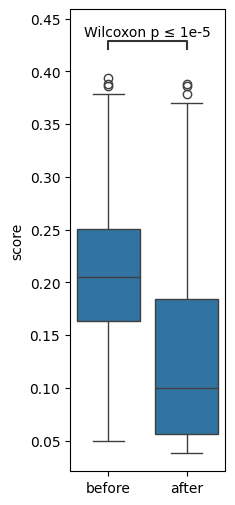

before vs. after: Wilcoxon test (paired samples), P_val:2.522e-48 Stat=0.000e+00


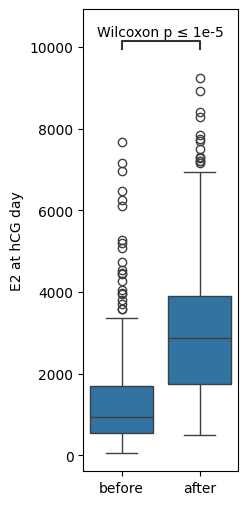

before vs. after: Wilcoxon test (paired samples), P_val:5.588e-49 Stat=0.000e+00


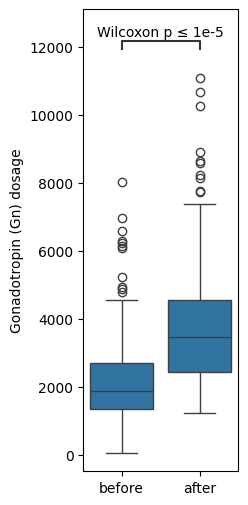

before vs. after: Wilcoxon test (paired samples), P_val:7.033e-42 Stat=0.000e+00


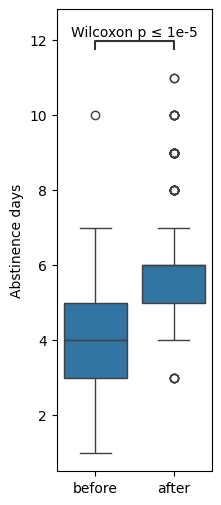

before vs. after: Wilcoxon test (paired samples), P_val:3.772e-46 Stat=0.000e+00


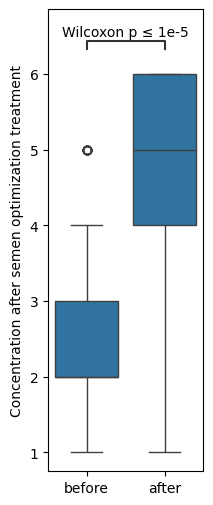

In [9]:
for index in suggest.index:
    _suggest = suggest.loc[index]
    _suggest = _suggest[~_suggest.str.contains("nan")]
    _suggest = _suggest.apply(ast.literal_eval)
    _suggest = pd.DataFrame(_suggest.tolist(), index=_suggest.index, columns=["before", "after"])
    _suggest = pd.melt(_suggest, var_name='type', value_name='value')

    plt.figure(figsize=(2, 6))
    ax = sns.boxplot(x='type', y='value', data=_suggest)

    pairs=[("before", "after")]
    annotator = Annotator(ax, pairs, data=_suggest, x="type", y="value")
    annotator.configure(test='Wilcoxon', text_format='simple')
    annotator.apply_and_annotate()

    ax.set_xlabel("")
    ax.set_ylabel(index)
    plt.savefig("suggest.{}.pdf".format(index), format="pdf", bbox_inches="tight")
    plt.show()

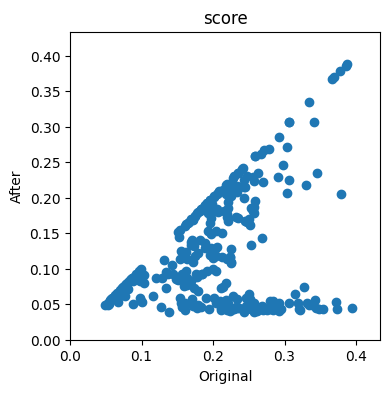

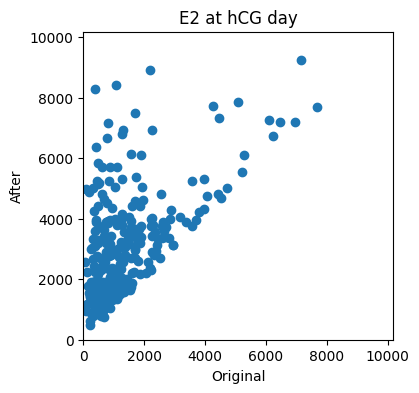

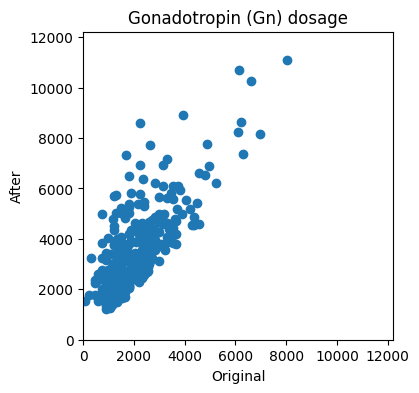

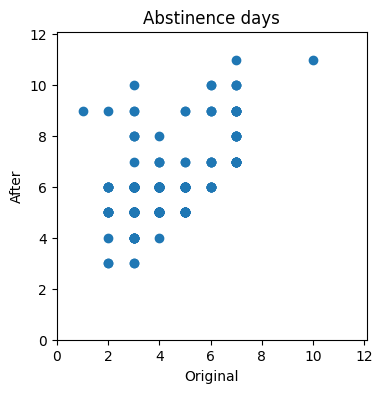

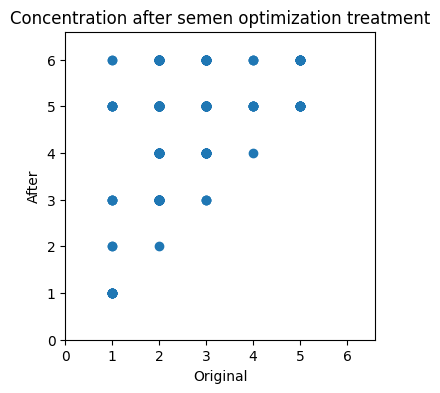

In [10]:
for index in suggest.index:
    _suggest = suggest.loc[index]
    _suggest = _suggest[~_suggest.str.contains("nan")]
    _suggest = _suggest.apply(ast.literal_eval)
    _suggest = pd.DataFrame(_suggest.tolist(), index=_suggest.index, columns=["before", "after"])

    plt.figure(figsize=(4, 4))
    plt.scatter(_suggest['before'], _suggest['after'])
    max_val = _suggest.max().max()
    plt.xlim(0, max_val * 1.1)
    plt.ylim(0, max_val * 1.1)
    # plt.axis('equal')

    plt.title(index)
    plt.xlabel('Original')
    plt.ylabel('After')
    plt.show()

In [11]:
# unchanged_sample = np.array([
#     [index, value[0]]
#     for index, value in suggest.loc["score"].apply(ast.literal_eval).items()
#     if value[0] == value[1]
# ])
# data.iloc[unchanged_sample[:, 0]]